# 12 — Final Supervised Model Evaluation

This notebook consolidates the final supervised-learning results for severe-rainfall nowcasting in Recife.

Final model selection is based exclusively on pre-2021 temporal validation performance obtained during model tuning.

For each forecasting horizon, the selected model is retrained using all eligible observations from 2018–2020 and evaluated once on the unseen 2021 test period.

The final analysis includes:

- precision, recall and F1-score;
- Critical Success Index (CSI);
- Average Precision (PR-AUC);
- ROC-AUC;
- confusion matrix;
- Precision-Recall curve;
- interpretation of the +1h Logistic Regression coefficients.

The 2021 test period is used only for final performance reporting.

=== DATASET LOADED ===

Rows: 33871
Start: 2018-01-01 00:00:00+00:00
End: 2021-11-12 06:00:00+00:00

=== FINAL PRE-2021 SELECTED CONFIGURATIONS ===


,horizon_hours,model,threshold,parameters
0,1,logistic_regression,0.99,{'C': 0.01}
1,2,random_forest,0.13,"{'max_depth': None, 'min_samples_leaf': 10}"
2,3,random_forest,0.77,"{'max_depth': 4, 'min_samples_leaf': 1}"
3,4,logistic_regression,0.94,{'C': 0.01}
4,5,logistic_regression,0.85,{'C': 0.01}
5,6,random_forest,0.57,"{'max_depth': 8, 'min_samples_leaf': 10}"



=== FINAL SELECTED MODEL RESULTS ===


,horizon_hours,model,threshold,test_positives,precision,recall,f1,csi,average_precision,roc_auc,true_positives,false_positives,false_negatives
0,1,logistic_regression,0.99,38,0.170,0.447,0.246,0.140,0.225,0.945,17,83,21
1,2,random_forest,0.13,38,0.056,0.395,0.098,0.051,0.076,0.866,15,254,23
2,3,random_forest,0.77,38,0.090,0.526,0.154,0.083,0.071,0.898,20,202,18
3,4,logistic_regression,0.94,38,0.097,0.368,0.153,0.083,0.075,0.897,14,131,24
4,5,logistic_regression,0.85,38,0.038,0.526,0.071,0.037,0.049,0.861,20,504,18
5,6,random_forest,0.57,38,0.032,0.237,0.056,0.029,0.022,0.821,9,272,29


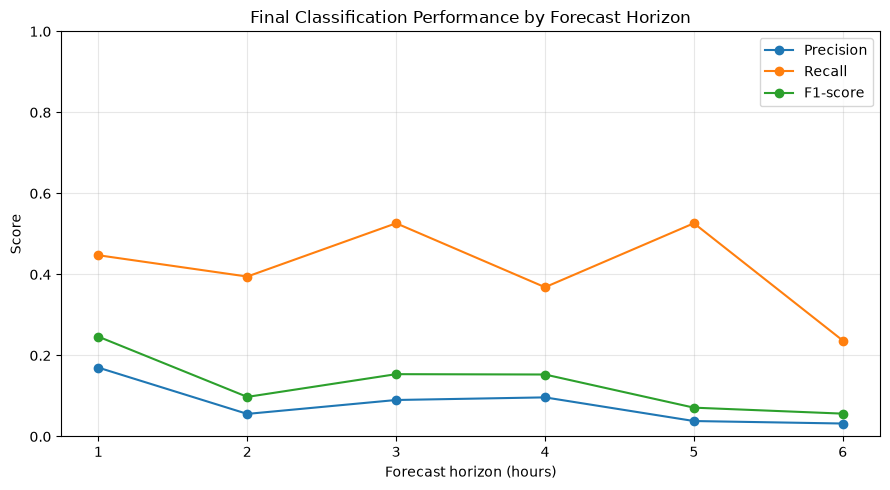

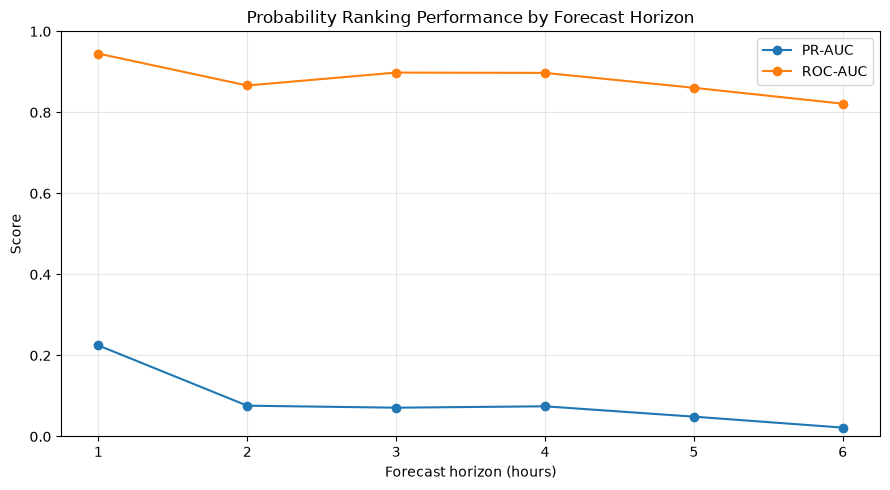

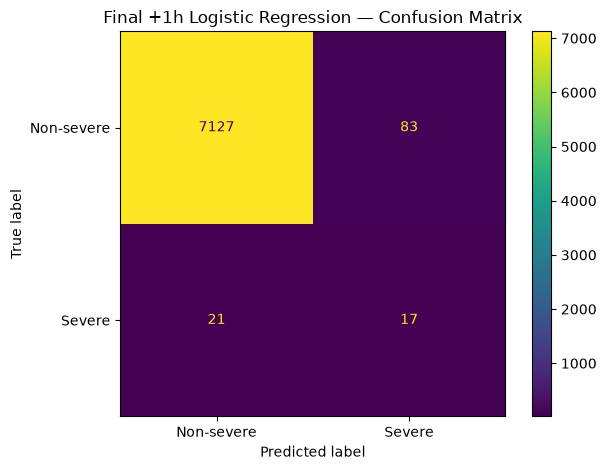

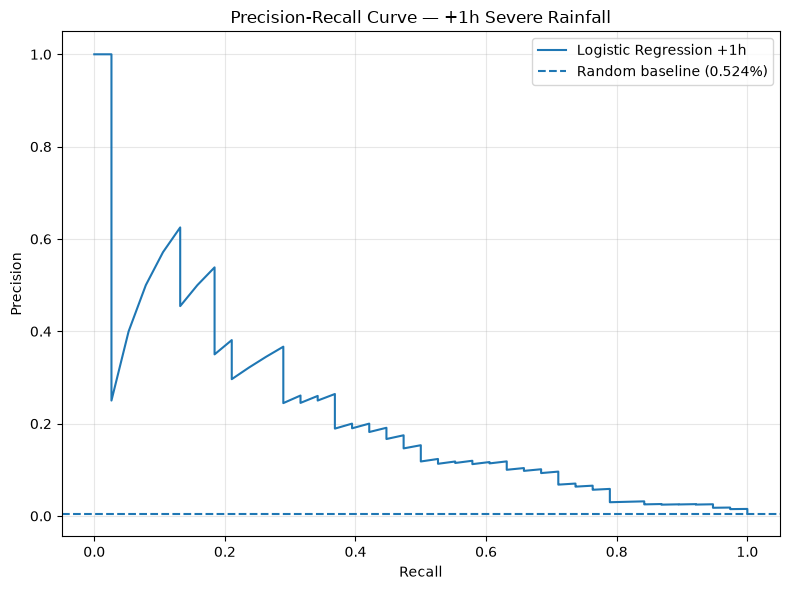


=== +1H LOGISTIC REGRESSION COEFFICIENTS ===


,feature,coefficient,absolute_coefficient
0,humidity_pct,1.793,1.793
1,humidity_pct_lag_1h,1.735,1.735
2,temperature_c_lag_1h,1.005,1.005
3,temperature_c,0.823,0.823
4,day_of_year_sin,0.544,0.544
5,temperature_change_1h,-0.506,0.506
6,precipitation_mm,0.489,0.489
7,day_of_year_cos,-0.355,0.355
8,precipitation_lag_3h,0.346,0.346
9,humidity_change_1h,0.153,0.153


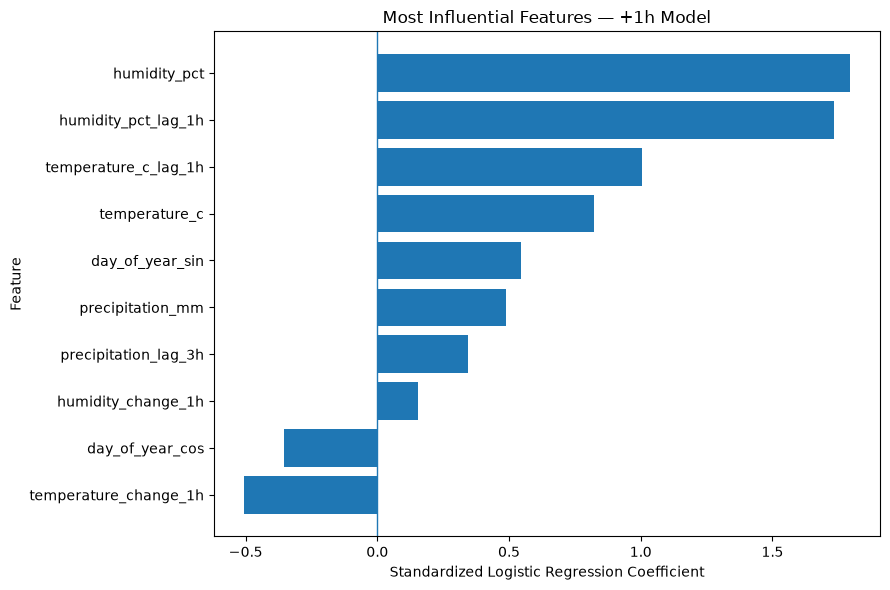


=== +1H BASELINE VS FINAL ===


,stage,precision,recall,f1,average_precision,roc_auc
0,baseline,0.016,0.947,0.031,0.206,0.925
1,final,0.170,0.447,0.246,0.225,0.945



=== FINAL PROJECT SUMMARY ===
Primary horizon: +1h
Model: logistic_regression
Precision: 0.17
Recall: 0.447
F1: 0.246
CSI: 0.14
PR-AUC: 0.225
ROC-AUC: 0.945

Final evaluation saved to:
..\data\processed\final_evaluation_results.csv

Figures saved to:
..\docs\figures


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)


# ============================================================
# 1. CONFIGURATION
# ============================================================

INPUT_PATH = Path(
    "../data/processed/recife_2018_2021_model_dataset.csv"
)

BASELINE_RESULTS_PATH = Path(
    "../data/processed/baseline_model_results.csv"
)

OUTPUT_PATH = Path(
    "../data/processed/final_evaluation_results.csv"
)

FIGURES_DIR = Path(
    "../docs/figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


TEST_START = pd.Timestamp(
    "2021-01-01 00:00",
    tz="UTC",
)

RANDOM_STATE = 42


# ============================================================
# 2. FEATURES
# ============================================================

FEATURE_COLUMNS = [
    "precipitation_mm",
    "temperature_c",
    "humidity_pct",
    "pressure_station_mb",

    "hour_sin",
    "hour_cos",
    "day_of_year_sin",
    "day_of_year_cos",

    "precipitation_lag_1h",
    "precipitation_lag_2h",
    "precipitation_lag_3h",
    "precipitation_lag_6h",
    "precipitation_sum_3h",
    "precipitation_sum_6h",

    "temperature_c_lag_1h",
    "humidity_pct_lag_1h",
    "pressure_station_mb_lag_1h",

    "temperature_change_1h",
    "humidity_change_1h",
    "pressure_change_1h",
]


# ============================================================
# 3. FINAL MODEL CONFIGURATIONS
#
# These choices were made using only pre-2021 validation data.
# ============================================================

FINAL_CONFIGURATIONS = {

    1: {
        "model": "logistic_regression",
        "parameters": {
            "C": 0.01,
        },
        "threshold": 0.99,
    },

    2: {
        "model": "random_forest",
        "parameters": {
            "max_depth": None,
            "min_samples_leaf": 10,
        },
        "threshold": 0.13,
    },

    3: {
        "model": "random_forest",
        "parameters": {
            "max_depth": 4,
            "min_samples_leaf": 1,
        },
        "threshold": 0.77,
    },

    4: {
        "model": "logistic_regression",
        "parameters": {
            "C": 0.01,
        },
        "threshold": 0.94,
    },

    5: {
        "model": "logistic_regression",
        "parameters": {
            "C": 0.01,
        },
        "threshold": 0.85,
    },

    6: {
        "model": "random_forest",
        "parameters": {
            "max_depth": 8,
            "min_samples_leaf": 10,
        },
        "threshold": 0.57,
    },
}


# ============================================================
# 4. MODEL FACTORY
# ============================================================

def build_model(
    model_name,
    parameters,
):

    if model_name == "logistic_regression":

        return Pipeline(
            steps=[
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "classifier",
                    LogisticRegression(
                        C=parameters["C"],
                        class_weight="balanced",
                        max_iter=3000,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        )


    if model_name == "random_forest":

        return RandomForestClassifier(
            n_estimators=300,

            max_depth=parameters[
                "max_depth"
            ],

            min_samples_leaf=parameters[
                "min_samples_leaf"
            ],

            class_weight="balanced_subsample",

            random_state=RANDOM_STATE,

            n_jobs=-1,
        )


    raise ValueError(
        f"Unknown model: {model_name}"
    )


# ============================================================
# 5. LOAD DATA
# ============================================================

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {INPUT_PATH}"
    )


df = pd.read_csv(
    INPUT_PATH,
    parse_dates=["datetime_utc"],
)

df = (
    df
    .set_index("datetime_utc")
    .sort_index()
)


print("=== DATASET LOADED ===")
print()

print(
    "Rows:",
    len(df)
)

print(
    "Start:",
    df.index.min()
)

print(
    "End:",
    df.index.max()
)


# ============================================================
# 6. DISPLAY FINAL CONFIGURATIONS
# ============================================================

configuration_rows = []


for horizon, config in FINAL_CONFIGURATIONS.items():

    configuration_rows.append(
        {
            "horizon_hours":
                horizon,

            "model":
                config["model"],

            "threshold":
                config["threshold"],

            "parameters":
                str(
                    config["parameters"]
                ),
        }
    )


configuration_df = pd.DataFrame(
    configuration_rows
)


print()
print(
    "=== FINAL PRE-2021 SELECTED CONFIGURATIONS ==="
)

display(
    configuration_df
)


# ============================================================
# 7. TRAIN FINAL MODELS AND TEST ON 2021
# ============================================================

final_results = []

fitted_models = {}

test_predictions = {}


for horizon, config in FINAL_CONFIGURATIONS.items():

    target_column = (
        f"target_{horizon}h"
    )

    eligibility_column = (
        f"eligible_final_{horizon}h"
    )


    eligible = df[
        df[eligibility_column]
    ].copy()


    train_data = eligible[
        eligible.index
        < TEST_START
    ]


    test_data = eligible[
        eligible.index
        >= TEST_START
    ]


    X_train = train_data[
        FEATURE_COLUMNS
    ]

    y_train = (
        train_data[
            target_column
        ]
        .astype(int)
    )


    X_test = test_data[
        FEATURE_COLUMNS
    ]

    y_test = (
        test_data[
            target_column
        ]
        .astype(int)
    )


    model = build_model(
        config["model"],
        config["parameters"],
    )


    model.fit(
        X_train,
        y_train,
    )


    probability = (
        model.predict_proba(
            X_test
        )[:, 1]
    )


    prediction = (
        probability
        >= config["threshold"]
    ).astype(int)


    precision = precision_score(
        y_test,
        prediction,
        zero_division=0,
    )

    recall = recall_score(
        y_test,
        prediction,
        zero_division=0,
    )

    f1 = f1_score(
        y_test,
        prediction,
        zero_division=0,
    )


    average_precision = (
        average_precision_score(
            y_test,
            probability,
        )
    )


    roc_auc = roc_auc_score(
        y_test,
        probability,
    )


    tn, fp, fn, tp = (
        confusion_matrix(
            y_test,
            prediction,
            labels=[0, 1],
        )
        .ravel()
    )


    csi_denominator = (
        tp
        + fp
        + fn
    )


    csi = (
        tp
        / csi_denominator
        if csi_denominator > 0
        else 0
    )


    prevalence = (
        y_test.mean()
    )


    final_results.append(
        {
            "horizon_hours":
                horizon,

            "model":
                config["model"],

            "threshold":
                config["threshold"],

            "train_samples":
                len(X_train),

            "train_positives":
                int(y_train.sum()),

            "test_samples":
                len(X_test),

            "test_positives":
                int(y_test.sum()),

            "test_prevalence_pct":
                prevalence * 100,

            "precision":
                precision,

            "recall":
                recall,

            "f1":
                f1,

            "csi":
                csi,

            "average_precision":
                average_precision,

            "roc_auc":
                roc_auc,

            "true_positives":
                int(tp),

            "false_positives":
                int(fp),

            "false_negatives":
                int(fn),

            "true_negatives":
                int(tn),
        }
    )


    fitted_models[
        horizon
    ] = model


    test_predictions[
        horizon
    ] = {
        "y_true":
            y_test.to_numpy(),

        "y_probability":
            probability,

        "y_prediction":
            prediction,

        "index":
            X_test.index,
    }


# ============================================================
# 8. FINAL RESULT TABLE
# ============================================================

final_results_df = pd.DataFrame(
    final_results
)


print()
print(
    "=== FINAL SELECTED MODEL RESULTS ==="
)

display(
    final_results_df[
        [
            "horizon_hours",
            "model",
            "threshold",
            "test_positives",
            "precision",
            "recall",
            "f1",
            "csi",
            "average_precision",
            "roc_auc",
            "true_positives",
            "false_positives",
            "false_negatives",
        ]
    ].round(3)
)


# ============================================================
# 9. SAVE FINAL RESULTS
# ============================================================

final_results_df.to_csv(
    OUTPUT_PATH,
    index=False,
)


# ============================================================
# 10. PLOT — PRECISION, RECALL AND F1
# ============================================================

plt.figure(
    figsize=(9, 5)
)


plt.plot(
    final_results_df[
        "horizon_hours"
    ],
    final_results_df[
        "precision"
    ],
    marker="o",
    label="Precision",
)


plt.plot(
    final_results_df[
        "horizon_hours"
    ],
    final_results_df[
        "recall"
    ],
    marker="o",
    label="Recall",
)


plt.plot(
    final_results_df[
        "horizon_hours"
    ],
    final_results_df[
        "f1"
    ],
    marker="o",
    label="F1-score",
)


plt.xlabel(
    "Forecast horizon (hours)"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Final Classification Performance by Forecast Horizon"
)

plt.xticks(
    [1, 2, 3, 4, 5, 6]
)

plt.ylim(
    0,
    1,
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()


plt.savefig(
    FIGURES_DIR
    / "final_classification_metrics.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 11. PLOT — PR-AUC AND ROC-AUC
# ============================================================

plt.figure(
    figsize=(9, 5)
)


plt.plot(
    final_results_df[
        "horizon_hours"
    ],
    final_results_df[
        "average_precision"
    ],
    marker="o",
    label="PR-AUC",
)


plt.plot(
    final_results_df[
        "horizon_hours"
    ],
    final_results_df[
        "roc_auc"
    ],
    marker="o",
    label="ROC-AUC",
)


plt.xlabel(
    "Forecast horizon (hours)"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Probability Ranking Performance by Forecast Horizon"
)

plt.xticks(
    [1, 2, 3, 4, 5, 6]
)

plt.ylim(
    0,
    1,
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()


plt.savefig(
    FIGURES_DIR
    / "final_ranking_metrics.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 12. +1H CONFUSION MATRIX
# ============================================================

horizon_1_data = (
    test_predictions[1]
)


cm_1h = confusion_matrix(
    horizon_1_data[
        "y_true"
    ],
    horizon_1_data[
        "y_prediction"
    ],
    labels=[
        0,
        1,
    ],
)


display_cm = (
    ConfusionMatrixDisplay(
        confusion_matrix=cm_1h,
        display_labels=[
            "Non-severe",
            "Severe",
        ],
    )
)


display_cm.plot(
    values_format="d",
)


plt.title(
    "Final +1h Logistic Regression — Confusion Matrix"
)

plt.tight_layout()


plt.savefig(
    FIGURES_DIR
    / "final_1h_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 13. +1H PRECISION-RECALL CURVE
# ============================================================

precision_curve, recall_curve, _ = (
    precision_recall_curve(
        horizon_1_data[
            "y_true"
        ],
        horizon_1_data[
            "y_probability"
        ],
    )
)


positive_rate = np.mean(
    horizon_1_data[
        "y_true"
    ]
)


plt.figure(
    figsize=(8, 6)
)


plt.plot(
    recall_curve,
    precision_curve,
    label="Logistic Regression +1h",
)


plt.axhline(
    y=positive_rate,
    linestyle="--",
    label=(
        "Random baseline "
        f"({positive_rate:.3%})"
    ),
)


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curve — +1h Severe Rainfall"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()


plt.savefig(
    FIGURES_DIR
    / "final_1h_precision_recall_curve.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 14. +1H LOGISTIC REGRESSION COEFFICIENTS
# ============================================================

model_1h = (
    fitted_models[1]
)


classifier_1h = (
    model_1h.named_steps[
        "classifier"
    ]
)


coefficients = (
    classifier_1h
    .coef_[0]
)


coefficient_df = pd.DataFrame(
    {
        "feature":
            FEATURE_COLUMNS,

        "coefficient":
            coefficients,

        "absolute_coefficient":
            np.abs(
                coefficients
            ),
    }
)


coefficient_df = (
    coefficient_df
    .sort_values(
        "absolute_coefficient",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


print()
print(
    "=== +1H LOGISTIC REGRESSION COEFFICIENTS ==="
)

display(
    coefficient_df.head(
        15
    ).round(3)
)


top_coefficients = (
    coefficient_df
    .head(10)
    .sort_values(
        "coefficient"
    )
)


plt.figure(
    figsize=(9, 6)
)


plt.barh(
    top_coefficients[
        "feature"
    ],
    top_coefficients[
        "coefficient"
    ],
)


plt.xlabel(
    "Standardized Logistic Regression Coefficient"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Most Influential Features — +1h Model"
)

plt.axvline(
    x=0,
    linewidth=1,
)

plt.tight_layout()


plt.savefig(
    FIGURES_DIR
    / "final_1h_logistic_coefficients.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 15. BASELINE VS FINAL +1H
# ============================================================

if BASELINE_RESULTS_PATH.exists():

    baseline_df = pd.read_csv(
        BASELINE_RESULTS_PATH
    )


    baseline_1h = baseline_df[
        (
            baseline_df[
                "horizon_hours"
            ]
            == 1
        )
        &
        (
            baseline_df[
                "model"
            ]
            == "logistic_regression"
        )
    ].iloc[0]


    final_1h = final_results_df[
        final_results_df[
            "horizon_hours"
        ]
        == 1
    ].iloc[0]


    comparison_1h = pd.DataFrame(
        [
            {
                "stage":
                    "baseline",

                "precision":
                    baseline_1h[
                        "precision"
                    ],

                "recall":
                    baseline_1h[
                        "recall"
                    ],

                "f1":
                    baseline_1h[
                        "f1"
                    ],

                "average_precision":
                    baseline_1h[
                        "average_precision"
                    ],

                "roc_auc":
                    baseline_1h[
                        "roc_auc"
                    ],
            },

            {
                "stage":
                    "final",

                "precision":
                    final_1h[
                        "precision"
                    ],

                "recall":
                    final_1h[
                        "recall"
                    ],

                "f1":
                    final_1h[
                        "f1"
                    ],

                "average_precision":
                    final_1h[
                        "average_precision"
                    ],

                "roc_auc":
                    final_1h[
                        "roc_auc"
                    ],
            },
        ]
    )


    print()
    print(
        "=== +1H BASELINE VS FINAL ==="
    )

    display(
        comparison_1h.round(3)
    )


# ============================================================
# 16. FINAL SUMMARY
# ============================================================

best_short_horizon = (
    final_results_df[
        final_results_df[
            "horizon_hours"
        ]
        == 1
    ]
    .iloc[0]
)


print()
print(
    "=== FINAL PROJECT SUMMARY ==="
)

print(
    "Primary horizon: +1h"
)

print(
    "Model:",
    best_short_horizon[
        "model"
    ]
)

print(
    "Precision:",
    round(
        best_short_horizon[
            "precision"
        ],
        3,
    )
)

print(
    "Recall:",
    round(
        best_short_horizon[
            "recall"
        ],
        3,
    )
)

print(
    "F1:",
    round(
        best_short_horizon[
            "f1"
        ],
        3,
    )
)

print(
    "CSI:",
    round(
        best_short_horizon[
            "csi"
        ],
        3,
    )
)

print(
    "PR-AUC:",
    round(
        best_short_horizon[
            "average_precision"
        ],
        3,
    )
)

print(
    "ROC-AUC:",
    round(
        best_short_horizon[
            "roc_auc"
        ],
        3,
    )
)


print()
print(
    "Final evaluation saved to:"
)

print(
    OUTPUT_PATH
)

print()
print(
    "Figures saved to:"
)

print(
    FIGURES_DIR
)

## Conclusion

The final evaluation confirmed that severe-rainfall predictability is strongest at the shortest forecasting horizon.

The final +1h Logistic Regression model achieved a precision of 0.170, recall of 0.447, F1-score of 0.246, CSI of 0.140, Average Precision of 0.225 and ROC-AUC of 0.945 on the unseen 2021 test period.

The model correctly identified 17 of the 38 severe-rainfall observations while generating 83 false-positive alerts.

Compared with the initial +1h Logistic Regression baseline, final threshold and model optimization substantially increased precision and F1-score while reducing excessive false-positive predictions.

Probability-ranking performance was strongest at +1h and generally deteriorated as the forecast horizon increased, indicating the increasing difficulty of severe-rainfall nowcasting several hours in advance using observations from a single surface meteorological station.

The Logistic Regression coefficient analysis indicates that current and recent relative humidity, temperature, current precipitation and recent precipitation history contribute strongly to the +1h classification. These coefficients represent statistical associations within the fitted model and should not be interpreted as causal meteorological relationships.

Together with the clustering analysis, these results demonstrate that both supervised and unsupervised machine-learning methods can extract meaningful severe-rainfall patterns from the available INMET observations.

The supervised model evaluation stage is now complete.